In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results_ext_nord_folder = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results'
results_nord_folder = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results'

cases_2025_file = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\CM_MAL_cases_GID2_2025_fixed_georeferenced.csv'

polygon_file = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\CM_WEB_Polygons.csv'

In [3]:
polygons = pd.read_csv(polygon_file)
polygons.rename(columns={'id': 'polygon_id'}, inplace=True)

In [4]:
cases_df = pd.read_csv(cases_2025_file)
cases_df = cases_df.merge(polygons, on='polygon_id', how='left')

cases_df_nord = cases_df[cases_df['gid0'] == 'nord'].copy()
cases_df_ext_nord = cases_df[cases_df['gid0'] == 'extreme nord'].copy()

cases_df_nord.reset_index(drop=True, inplace=True)
cases_df_ext_nord.reset_index(drop=True, inplace=True)

In [5]:
with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges.pkl', 'rb') as f:
    nord_ranges = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges_und5.pkl', 'rb') as f:
    nord_ranges_und5 = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges_ovr5.pkl', 'rb') as f:
    nord_ranges_ovr5 = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges_prgn.pkl', 'rb') as f:
    nord_ranges_prgn = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges_severe.pkl', 'rb') as f:
    nord_ranges_severe = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\modeling\saved\CM_Nord_bin_ranges_hospitalization.pkl', 'rb') as f:
    nord_ranges_hosp = pickle.load(f)

print(nord_ranges)
print(nord_ranges_und5)
print(nord_ranges_ovr5)
print(nord_ranges_prgn)
print(nord_ranges_severe)
print(nord_ranges_hosp)

[0, 1, 16, 32, 64, 128, 256, 512, 3666]
[0, 1, 8, 16, 32, 64, 128, 256, 3641]
[0, 1, 8, 16, 32, 64, 128, 256, 1621]
[0, 1, 4, 8, 16, 32, 64, 244]
[0, 1, 8, 16, 32, 64, 128, 256, 3660]
[0, 1, 8, 16, 32, 64, 128, 256, 1220]


In [6]:
with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges.pkl', 'rb') as f:
    ext_nord_ranges = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges_und5.pkl', 'rb') as f:
    ext_nord_ranges_und5 = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges_ovr5.pkl', 'rb') as f:
    ext_nord_ranges_ovr5 = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges_prgn.pkl', 'rb') as f:
    ext_nord_ranges_prgn = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges_severe.pkl', 'rb') as f:
    ext_nord_ranges_severe = pickle.load(f)

with open(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\ExtNord\modeling\saved\CM_ExtNord_bin_ranges_hospitalization.pkl', 'rb') as f:
    ext_nord_ranges_hosp = pickle.load(f)

print(ext_nord_ranges)
print(ext_nord_ranges_und5)
print(ext_nord_ranges_ovr5)
print(ext_nord_ranges_prgn)
print(ext_nord_ranges_severe)
print(ext_nord_ranges_hosp)

[0, 1, 6, 16, 32, 64, 128, 256, 512, 8023]
[0, 1, 4, 8, 16, 32, 64, 128, 256, 2507]
[0, 1, 4, 8, 16, 32, 64, 128, 256, 7940]
[0, 1, 4, 8, 16, 32, 64, 419]
[0, 1, 4, 8, 16, 32, 64, 128, 256, 3057]
[0, 1, 6, 16, 32, 64, 128, 256, 3237]


In [7]:
bin_map_ext_nord = {
    "Case_UND5": ext_nord_ranges_und5,
    "Case_OVR5": ext_nord_ranges_ovr5,
    "Case_PRGN": ext_nord_ranges_prgn,
    "Case_TOTAL": ext_nord_ranges,
    "Sevr_TOTAL": ext_nord_ranges_severe,
    "Hosp_TOTAL": ext_nord_ranges_hosp,
}

for col, bins in bin_map_ext_nord.items():
    labels = range(len(bins) - 1)
    cases_df_ext_nord[f"{col}"] = pd.cut(
        cases_df_ext_nord[col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False,
    )

In [8]:
bin_map_nord = {
    "Case_UND5": nord_ranges_und5,
    "Case_OVR5": nord_ranges_ovr5,
    "Case_PRGN": nord_ranges_prgn,
    "Case_TOTAL": nord_ranges,
    "Sevr_TOTAL": nord_ranges_severe,
    "Hosp_TOTAL": nord_ranges_hosp,
}

for col, bins in bin_map_nord.items():
    labels = range(len(bins) - 1)
    cases_df_nord[f"{col}"] = pd.cut(
        cases_df_nord[col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False,
    )

In [9]:
results_nord_1 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01.csv")
results_nord_2 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02.csv")
results_nord_3 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03.csv")
results_nord_4 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04.csv")
results_nord_5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05.csv")
results_nord_6 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06.csv")
results_nord_7 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07.csv")
results_nord_8 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08.csv")
results_nord_9 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09.csv")
results_nord_10 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10.csv")
results_nord_11 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11.csv")
results_nord_12 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12.csv") 

results_nord = pd.concat([
    results_nord_1, results_nord_2, results_nord_3, results_nord_4, results_nord_5, results_nord_6,
    results_nord_7, results_nord_8, results_nord_9, results_nord_10, results_nord_11, results_nord_12
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord = results_nord.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord["actual"], errors="coerce")

results_nord["abs_error"] = (actual - results_nord["prediction"]).abs()

results_nord

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Total Malaria Cases,7,2024-10,2025-01,4,4,0.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Total Malaria Cases,7,2024-10,2025-01,5,5,0.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Total Malaria Cases,7,2024-10,2025-01,4,4,0.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Total Malaria Cases,7,2024-10,2025-01,4,3,1.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Total Malaria Cases,7,2024-10,2025-01,3,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Total Malaria Cases,7,2025-09,2025-12,5,5,0.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Total Malaria Cases,7,2025-09,2025-12,5,6,1.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Total Malaria Cases,7,2025-09,2025-12,6,7,1.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Total Malaria Cases,7,2025-09,2025-12,5,6,1.0


In [10]:
results_nord_1_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01_und5.csv")
results_nord_2_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02_und5.csv")
results_nord_3_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03_und5.csv")
results_nord_4_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04_und5.csv")
results_nord_5_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05_und5.csv")
results_nord_6_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06_und5.csv")
results_nord_7_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07_und5.csv")
results_nord_8_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08_und5.csv")
results_nord_9_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09_und5.csv")
results_nord_10_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10_und5.csv")
results_nord_11_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11_und5.csv")
results_nord_12_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12_und5.csv") 

results_nord_und5 = pd.concat([
    results_nord_1_und5, results_nord_2_und5, results_nord_3_und5, results_nord_4_und5, results_nord_5_und5, results_nord_6_und5,
    results_nord_7_und5, results_nord_8_und5, results_nord_9_und5, results_nord_10_und5, results_nord_11_und5, results_nord_12_und5
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord_und5 = results_nord_und5.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord_und5["actual"], errors="coerce")

results_nord_und5["abs_error"] = (actual - results_nord_und5["prediction"]).abs()

results_nord_und5

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Malaria Cases Under 5 Years,7,2024-10,2025-01,4,4,0.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Malaria Cases Under 5 Years,7,2024-10,2025-01,5,5,0.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Malaria Cases Under 5 Years,7,2024-10,2025-01,3,4,1.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Malaria Cases Under 5 Years,7,2024-10,2025-01,4,3,1.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Malaria Cases Under 5 Years,7,2024-10,2025-01,3,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Malaria Cases Under 5 Years,7,2025-09,2025-12,3,5,2.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Malaria Cases Under 5 Years,7,2025-09,2025-12,5,6,1.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Malaria Cases Under 5 Years,7,2025-09,2025-12,5,7,2.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Malaria Cases Under 5 Years,7,2025-09,2025-12,5,6,1.0


In [11]:
results_nord_1_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01_ovr5.csv")
results_nord_2_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02_ovr5.csv")
results_nord_3_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03_ovr5.csv")
results_nord_4_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04_ovr5.csv")
results_nord_5_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05_ovr5.csv")
results_nord_6_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06_ovr5.csv")
results_nord_7_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07_ovr5.csv")
results_nord_8_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08_ovr5.csv")
results_nord_9_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09_ovr5.csv")
results_nord_10_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10_ovr5.csv")
results_nord_11_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11_ovr5.csv")
results_nord_12_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12_ovr5.csv") 

results_nord_ovr5 = pd.concat([
    results_nord_1_ovr5, results_nord_2_ovr5, results_nord_3_ovr5, results_nord_4_ovr5, results_nord_5_ovr5, results_nord_6_ovr5,
    results_nord_7_ovr5, results_nord_8_ovr5, results_nord_9_ovr5, results_nord_10_ovr5, results_nord_11_ovr5, results_nord_12_ovr5
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord_ovr5 = results_nord_ovr5.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord_ovr5["actual"], errors="coerce")

results_nord_ovr5["abs_error"] = (actual - results_nord_ovr5["prediction"]).abs()

results_nord_ovr5

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Malaria Cases Over 5 Years,7,2024-10,2025-01,4,4,0.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Malaria Cases Over 5 Years,7,2024-10,2025-01,5,5,0.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Malaria Cases Over 5 Years,7,2024-10,2025-01,4,4,0.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Malaria Cases Over 5 Years,7,2024-10,2025-01,3,3,0.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Malaria Cases Over 5 Years,7,2024-10,2025-01,2,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Malaria Cases Over 5 Years,7,2025-09,2025-12,3,5,2.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Malaria Cases Over 5 Years,7,2025-09,2025-12,5,6,1.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Malaria Cases Over 5 Years,7,2025-09,2025-12,5,7,2.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Malaria Cases Over 5 Years,7,2025-09,2025-12,5,6,1.0


In [12]:
results_nord_1_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01_prgn.csv")
results_nord_2_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02_prgn.csv")
results_nord_3_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03_prgn.csv")
results_nord_4_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04_prgn.csv")
results_nord_5_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05_prgn.csv")
results_nord_6_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06_prgn.csv")
results_nord_7_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07_prgn.csv")
results_nord_8_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08_prgn.csv")
results_nord_9_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09_prgn.csv")
results_nord_10_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10_prgn.csv")
results_nord_11_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11_prgn.csv")
results_nord_12_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12_prgn.csv") 

results_nord_prgn = pd.concat([
    results_nord_1_prgn, results_nord_2_prgn, results_nord_3_prgn, results_nord_4_prgn, results_nord_5_prgn, results_nord_6_prgn,
    results_nord_7_prgn, results_nord_8_prgn, results_nord_9_prgn, results_nord_10_prgn, results_nord_11_prgn, results_nord_12_prgn
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord_prgn = results_nord_prgn.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord_prgn["actual"], errors="coerce")

results_nord_prgn["abs_error"] = (actual - results_nord_prgn["prediction"]).abs()

results_nord_prgn

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Malaria Cases in Pregnant Women,6,2024-10,2025-01,2,4,2.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Malaria Cases in Pregnant Women,6,2024-10,2025-01,3,5,2.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Malaria Cases in Pregnant Women,6,2024-10,2025-01,1,4,3.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Malaria Cases in Pregnant Women,6,2024-10,2025-01,4,3,1.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Malaria Cases in Pregnant Women,6,2024-10,2025-01,2,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Malaria Cases in Pregnant Women,6,2025-09,2025-12,2,5,3.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Malaria Cases in Pregnant Women,6,2025-09,2025-12,3,6,3.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Malaria Cases in Pregnant Women,6,2025-09,2025-12,5,7,2.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Malaria Cases in Pregnant Women,6,2025-09,2025-12,4,6,2.0


In [13]:
results_nord_1_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01_severe.csv")
results_nord_2_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02_severe.csv")
results_nord_3_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03_severe.csv")
results_nord_4_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04_severe.csv")
results_nord_5_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05_severe.csv")
results_nord_6_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06_severe.csv")
results_nord_7_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07_severe.csv")
results_nord_8_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08_severe.csv")
results_nord_9_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09_severe.csv")
results_nord_10_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10_severe.csv")
results_nord_11_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11_severe.csv")
results_nord_12_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12_severe.csv") 

results_nord_severe = pd.concat([
    results_nord_1_severe, results_nord_2_severe, results_nord_3_severe, results_nord_4_severe, results_nord_5_severe, results_nord_6_severe,
    results_nord_7_severe, results_nord_8_severe, results_nord_9_severe, results_nord_10_severe, results_nord_11_severe, results_nord_12_severe
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord_severe = results_nord_severe.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord_severe["actual"], errors="coerce")

results_nord_severe["abs_error"] = (actual - results_nord_severe["prediction"]).abs()

results_nord_severe

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Total Severe Malaria Cases,7,2024-10,2025-01,4,4,0.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Total Severe Malaria Cases,7,2024-10,2025-01,5,5,0.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Total Severe Malaria Cases,7,2024-10,2025-01,3,4,1.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Total Severe Malaria Cases,7,2024-10,2025-01,5,3,2.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Total Severe Malaria Cases,7,2024-10,2025-01,2,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Total Severe Malaria Cases,7,2025-09,2025-12,3,5,2.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Total Severe Malaria Cases,7,2025-09,2025-12,5,6,1.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Total Severe Malaria Cases,7,2025-09,2025-12,6,7,1.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Total Severe Malaria Cases,7,2025-09,2025-12,6,6,0.0


In [14]:
results_nord_1_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-01_hospitalization.csv")
results_nord_2_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-02_hospitalization.csv")
results_nord_3_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-03_hospitalization.csv")
results_nord_4_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-04_hospitalization.csv")
results_nord_5_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-05_hospitalization.csv")
results_nord_6_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-06_hospitalization.csv")
results_nord_7_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-07_hospitalization.csv")
results_nord_8_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-08_hospitalization.csv")
results_nord_9_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-09_hospitalization.csv")
results_nord_10_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-10_hospitalization.csv")
results_nord_11_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-11_hospitalization.csv")
results_nord_12_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Nord\results\CM_Nord_Inference_2025-12_hospitalization.csv") 

results_nord_hosp = pd.concat([
    results_nord_1_hosp, results_nord_2_hosp, results_nord_3_hosp, results_nord_4_hosp, results_nord_5_hosp, results_nord_6_hosp,
    results_nord_7_hosp, results_nord_8_hosp, results_nord_9_hosp, results_nord_10_hosp, results_nord_11_hosp, results_nord_12_hosp
], ignore_index=True)

df_temp = cases_df_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_nord_hosp = results_nord_hosp.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_nord_hosp["actual"], errors="coerce")

results_nord_hosp["abs_error"] = (actual - results_nord_hosp["prediction"]).abs()

results_nord_hosp

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('nord', 'benoue', 'bibemi', 'adoumri')",73,13.770202,9.240232,Total Malaria Hospitalizations,7,2024-10,2025-01,3,4,1.0
1,"('nord', 'benoue', 'bibemi', 'bibemi')",71,13.949181,9.263633,Total Malaria Hospitalizations,7,2024-10,2025-01,5,5,0.0
2,"('nord', 'benoue', 'bibemi', 'bide')",67,13.972945,9.422292,Total Malaria Hospitalizations,7,2024-10,2025-01,3,4,1.0
3,"('nord', 'benoue', 'bibemi', 'dengui')",76,13.642496,9.235656,Total Malaria Hospitalizations,7,2024-10,2025-01,4,3,1.0
4,"('nord', 'benoue', 'bibemi', 'djaloumi')",68,13.994667,9.585190,Total Malaria Hospitalizations,7,2024-10,2025-01,2,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1735,"('nord', 'mayo-rey', 'touboro', 'mbeing')",127,15.001895,7.650008,Total Malaria Hospitalizations,7,2025-09,2025-12,3,5,2.0
1736,"('nord', 'mayo-rey', 'touboro', 'ngai-lara')",59,15.110765,7.963850,Total Malaria Hospitalizations,7,2025-09,2025-12,5,6,1.0
1737,"('nord', 'mayo-rey', 'touboro', 'touboro')",57,15.293957,7.759324,Total Malaria Hospitalizations,7,2025-09,2025-12,6,7,1.0
1738,"('nord', 'mayo-rey', 'touboro', 'vogzom')",62,14.714359,7.747549,Total Malaria Hospitalizations,7,2025-09,2025-12,5,6,1.0


In [15]:
results_ext_nord_1 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01.csv")
results_ext_nord_2 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02.csv")
results_ext_nord_3 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03.csv")
results_ext_nord_4 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04.csv")
results_ext_nord_5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05.csv")
results_ext_nord_6 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06.csv")
results_ext_nord_7 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07.csv")
results_ext_nord_8 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08.csv")
results_ext_nord_9 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09.csv")
results_ext_nord_10 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10.csv")
results_ext_nord_11 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11.csv")
results_ext_nord_12 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12.csv") 

results_ext_nord = pd.concat([
    results_ext_nord_1, results_ext_nord_2, results_ext_nord_3, results_ext_nord_4, results_ext_nord_5, results_ext_nord_6,
    results_ext_nord_7, results_ext_nord_8, results_ext_nord_9, results_ext_nord_10, results_ext_nord_11, results_ext_nord_12
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord = results_ext_nord.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord["actual"], errors="coerce")

results_ext_nord["abs_error"] = (actual - results_ext_nord["prediction"]).abs()

results_ext_nord

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Total Malaria Cases,8,2024-10,2025-01,7,6,1.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Total Malaria Cases,8,2024-10,2025-01,6,6,0.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Total Malaria Cases,8,2024-10,2025-01,7,7,0.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Total Malaria Cases,8,2024-10,2025-01,5,6,1.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Total Malaria Cases,8,2024-10,2025-01,6,6,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Total Malaria Cases,8,2025-09,2025-12,4,4,0.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Total Malaria Cases,8,2025-09,2025-12,4,4,0.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Total Malaria Cases,8,2025-09,2025-12,5,4,1.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Total Malaria Cases,8,2025-09,2025-12,4,6,2.0


In [16]:
results_ext_nord_1_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01_und5.csv")
results_ext_nord_2_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02_und5.csv")
results_ext_nord_3_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03_und5.csv")
results_ext_nord_4_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04_und5.csv")
results_ext_nord_5_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05_und5.csv")
results_ext_nord_6_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06_und5.csv")
results_ext_nord_7_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07_und5.csv")
results_ext_nord_8_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08_und5.csv")
results_ext_nord_9_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09_und5.csv")
results_ext_nord_10_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10_und5.csv")
results_ext_nord_11_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11_und5.csv")
results_ext_nord_12_und5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12_und5.csv") 

results_ext_nord_und5 = pd.concat([
    results_ext_nord_1_und5, results_ext_nord_2_und5, results_ext_nord_3_und5, results_ext_nord_4_und5, results_ext_nord_5_und5, results_ext_nord_6_und5,
    results_ext_nord_7_und5, results_ext_nord_8_und5, results_ext_nord_9_und5, results_ext_nord_10_und5, results_ext_nord_11_und5, results_ext_nord_12_und5
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord_und5 = results_ext_nord_und5.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord_und5["actual"], errors="coerce")

results_ext_nord_und5["abs_error"] = (actual - results_ext_nord_und5["prediction"]).abs()

results_ext_nord_und5

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Malaria Cases Under 5 Years,8,2024-10,2025-01,6,6,0.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Malaria Cases Under 5 Years,8,2024-10,2025-01,5,6,1.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Malaria Cases Under 5 Years,8,2024-10,2025-01,6,7,1.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Malaria Cases Under 5 Years,8,2024-10,2025-01,5,6,1.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Malaria Cases Under 5 Years,8,2024-10,2025-01,5,6,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Malaria Cases Under 5 Years,8,2025-09,2025-12,4,4,0.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Malaria Cases Under 5 Years,8,2025-09,2025-12,4,4,0.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Malaria Cases Under 5 Years,8,2025-09,2025-12,4,4,0.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Malaria Cases Under 5 Years,8,2025-09,2025-12,4,6,2.0


In [17]:
results_ext_nord_1_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01_ovr5.csv")
results_ext_nord_2_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02_ovr5.csv")
results_ext_nord_3_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03_ovr5.csv")
results_ext_nord_4_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04_ovr5.csv")
results_ext_nord_5_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05_ovr5.csv")
results_ext_nord_6_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06_ovr5.csv")
results_ext_nord_7_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07_ovr5.csv")
results_ext_nord_8_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08_ovr5.csv")
results_ext_nord_9_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09_ovr5.csv")
results_ext_nord_10_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10_ovr5.csv")
results_ext_nord_11_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11_ovr5.csv")
results_ext_nord_12_ovr5 = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12_ovr5.csv") 

results_ext_nord_ovr5 = pd.concat([
    results_ext_nord_1_ovr5, results_ext_nord_2_ovr5, results_ext_nord_3_ovr5, results_ext_nord_4_ovr5, results_ext_nord_5_ovr5, results_ext_nord_6_ovr5,
    results_ext_nord_7_ovr5, results_ext_nord_8_ovr5, results_ext_nord_9_ovr5, results_ext_nord_10_ovr5, results_ext_nord_11_ovr5, results_ext_nord_12_ovr5
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord_ovr5 = results_ext_nord_ovr5.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord_ovr5["actual"], errors="coerce")

results_ext_nord_ovr5["abs_error"] = (actual - results_ext_nord_ovr5["prediction"]).abs()

results_ext_nord_ovr5

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Malaria Cases Over 5 Years,8,2024-10,2025-01,6,6,0.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Malaria Cases Over 5 Years,8,2024-10,2025-01,5,6,1.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Malaria Cases Over 5 Years,8,2024-10,2025-01,7,7,0.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Malaria Cases Over 5 Years,8,2024-10,2025-01,5,6,1.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Malaria Cases Over 5 Years,8,2024-10,2025-01,5,6,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Malaria Cases Over 5 Years,8,2025-09,2025-12,4,4,0.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Malaria Cases Over 5 Years,8,2025-09,2025-12,3,4,1.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Malaria Cases Over 5 Years,8,2025-09,2025-12,4,4,0.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Malaria Cases Over 5 Years,8,2025-09,2025-12,4,6,2.0


In [18]:
results_ext_nord_1_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01_prgn.csv")
results_ext_nord_2_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02_prgn.csv")
results_ext_nord_3_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03_prgn.csv")
results_ext_nord_4_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04_prgn.csv")
results_ext_nord_5_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05_prgn.csv")
results_ext_nord_6_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06_prgn.csv")
results_ext_nord_7_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07_prgn.csv")
results_ext_nord_8_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08_prgn.csv")
results_ext_nord_9_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09_prgn.csv")
results_ext_nord_10_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10_prgn.csv")
results_ext_nord_11_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11_prgn.csv")
results_ext_nord_12_prgn = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12_prgn.csv") 

results_ext_nord_prgn = pd.concat([
    results_ext_nord_1_prgn, results_ext_nord_2_prgn, results_ext_nord_3_prgn, results_ext_nord_4_prgn, results_ext_nord_5_prgn, results_ext_nord_6_prgn,
    results_ext_nord_7_prgn, results_ext_nord_8_prgn, results_ext_nord_9_prgn, results_ext_nord_10_prgn, results_ext_nord_11_prgn, results_ext_nord_12_prgn
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord_prgn = results_ext_nord_prgn.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord_prgn["actual"], errors="coerce")

results_ext_nord_prgn["abs_error"] = (actual - results_ext_nord_prgn["prediction"]).abs()

results_ext_nord_prgn

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Malaria Cases in Pregnant Women,6,2024-10,2025-01,4,6,2.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Malaria Cases in Pregnant Women,6,2024-10,2025-01,2,6,4.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Malaria Cases in Pregnant Women,6,2024-10,2025-01,5,7,2.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Malaria Cases in Pregnant Women,6,2024-10,2025-01,1,6,5.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Malaria Cases in Pregnant Women,6,2024-10,2025-01,2,6,4.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Malaria Cases in Pregnant Women,6,2025-09,2025-12,1,4,3.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Malaria Cases in Pregnant Women,6,2025-09,2025-12,1,4,3.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Malaria Cases in Pregnant Women,6,2025-09,2025-12,1,4,3.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Malaria Cases in Pregnant Women,6,2025-09,2025-12,1,6,5.0


In [19]:
results_ext_nord_1_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01_severe.csv")
results_ext_nord_2_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02_severe.csv")
results_ext_nord_3_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03_severe.csv")
results_ext_nord_4_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04_severe.csv")
results_ext_nord_5_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05_severe.csv")
results_ext_nord_6_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06_severe.csv")
results_ext_nord_7_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07_severe.csv")
results_ext_nord_8_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08_severe.csv")
results_ext_nord_9_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09_severe.csv")
results_ext_nord_10_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10_severe.csv")
results_ext_nord_11_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11_severe.csv")
results_ext_nord_12_severe = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12_severe.csv") 

results_ext_nord_severe = pd.concat([
    results_ext_nord_1_severe, results_ext_nord_2_severe, results_ext_nord_3_severe, results_ext_nord_4_severe, results_ext_nord_5_severe, results_ext_nord_6_severe,
    results_ext_nord_7_severe, results_ext_nord_8_severe, results_ext_nord_9_severe, results_ext_nord_10_severe, results_ext_nord_11_severe, results_ext_nord_12_severe
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord_severe = results_ext_nord_severe.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord_severe["actual"], errors="coerce")

results_ext_nord_severe["abs_error"] = (actual - results_ext_nord_severe["prediction"]).abs()

results_ext_nord_severe

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Total Severe Malaria Cases,8,2024-10,2025-01,5,6,1.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Total Severe Malaria Cases,8,2024-10,2025-01,5,6,1.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Total Severe Malaria Cases,8,2024-10,2025-01,6,7,1.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Total Severe Malaria Cases,8,2024-10,2025-01,4,6,2.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Total Severe Malaria Cases,8,2024-10,2025-01,5,6,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Total Severe Malaria Cases,8,2025-09,2025-12,3,4,1.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Total Severe Malaria Cases,8,2025-09,2025-12,3,4,1.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Total Severe Malaria Cases,8,2025-09,2025-12,4,4,0.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Total Severe Malaria Cases,8,2025-09,2025-12,4,6,2.0


In [20]:
results_ext_nord_1_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-01_hospitalization.csv")
results_ext_nord_2_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-02_hospitalization.csv")
results_ext_nord_3_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-03_hospitalization.csv")
results_ext_nord_4_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-04_hospitalization.csv")
results_ext_nord_5_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-05_hospitalization.csv")
results_ext_nord_6_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-06_hospitalization.csv")
results_ext_nord_7_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-07_hospitalization.csv")
results_ext_nord_8_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-08_hospitalization.csv")
results_ext_nord_9_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-09_hospitalization.csv")
results_ext_nord_10_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-10_hospitalization.csv")
results_ext_nord_11_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-11_hospitalization.csv")
results_ext_nord_12_hosp = pd.read_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\ExtNord\results\CM_ExtNord_Inference_2025-12_hospitalization.csv") 

results_ext_nord_hosp = pd.concat([
    results_ext_nord_1_hosp, results_ext_nord_2_hosp, results_ext_nord_3_hosp, results_ext_nord_4_hosp, results_ext_nord_5_hosp, results_ext_nord_6_hosp,
    results_ext_nord_7_hosp, results_ext_nord_8_hosp, results_ext_nord_9_hosp, results_ext_nord_10_hosp, results_ext_nord_11_hosp, results_ext_nord_12_hosp
], ignore_index=True)

df_temp = cases_df_ext_nord.rename(columns={"Case_TOTAL": "actual"})[["polygon_id", "dt_placement", "actual"]]

results_ext_nord_hosp = results_ext_nord_hosp.merge(
    df_temp,
    left_on=["polygon_id", "dt_reference"],
    right_on=["polygon_id", "dt_placement"],
    how="left"
).drop(columns="dt_placement")

actual = pd.to_numeric(results_ext_nord_hosp["actual"], errors="coerce")

results_ext_nord_hosp["abs_error"] = (actual - results_ext_nord_hosp["prediction"]).abs()

results_ext_nord_hosp

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Total Malaria Hospitalizations,7,2024-10,2025-01,5,6,1.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Total Malaria Hospitalizations,7,2024-10,2025-01,4,6,2.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Total Malaria Hospitalizations,7,2024-10,2025-01,6,7,1.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Total Malaria Hospitalizations,7,2024-10,2025-01,3,6,3.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Total Malaria Hospitalizations,7,2024-10,2025-01,4,6,2.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Total Malaria Hospitalizations,7,2025-09,2025-12,2,6,4.0


In [21]:
results_nord
results_nord_und5
results_nord_ovr5
results_nord_prgn
results_nord_severe
results_nord_hosp
results_ext_nord
results_ext_nord_und5
results_ext_nord_ovr5
results_ext_nord_prgn
results_ext_nord_severe
results_ext_nord_hosp

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,actual,abs_error
0,"('extreme nord', 'diamare', 'bogo', 'balaza')",372,14.515776,10.786560,Total Malaria Hospitalizations,7,2024-10,2025-01,5,6,1.0
1,"('extreme nord', 'diamare', 'bogo', 'balda')",310,14.724237,10.914551,Total Malaria Hospitalizations,7,2024-10,2025-01,4,6,2.0
2,"('extreme nord', 'diamare', 'bogo', 'bogo')",311,14.597860,10.743440,Total Malaria Hospitalizations,7,2024-10,2025-01,6,7,1.0
3,"('extreme nord', 'diamare', 'bogo', 'borai')",313,14.606980,10.653607,Total Malaria Hospitalizations,7,2024-10,2025-01,3,6,3.0
4,"('extreme nord', 'diamare', 'bogo', 'guinggley')",312,14.702740,10.792848,Total Malaria Hospitalizations,7,2024-10,2025-01,4,6,2.0
...,...,...,...,...,...,...,...,...,...,...,...
3799,"('extreme nord', 'mayo-tsanaga', 'roua', 'midre')",367,13.871290,10.791350,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3800,"('extreme nord', 'mayo-tsanaga', 'roua', 'ndim...",428,13.968570,10.827287,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3801,"('extreme nord', 'mayo-tsanaga', 'roua', 'roua')",411,13.968570,10.779370,Total Malaria Hospitalizations,7,2025-09,2025-12,2,4,2.0
3802,"('extreme nord', 'mayo-tsanaga', 'roua', 'soul...",368,13.917498,10.736254,Total Malaria Hospitalizations,7,2025-09,2025-12,2,6,4.0


In [22]:
results_ext_nord.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025.csv", index=False)
results_ext_nord_und5.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025_und5.csv", index=False)
results_ext_nord_ovr5.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025_ovr5.csv", index=False)
results_ext_nord_prgn.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025_prgn.csv", index=False)
results_ext_nord_severe.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025_severe.csv", index=False)
results_ext_nord_hosp.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_ExtNord_Results_2025_hospitalization.csv", index=False)

results_nord.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025.csv", index=False)
results_nord_und5.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025_und5.csv", index=False)
results_nord_ovr5.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025_ovr5.csv", index=False)
results_nord_prgn.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025_prgn.csv", index=False)
results_nord_severe.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025_severe.csv", index=False)
results_nord_hosp.to_csv(r"E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\data\Validation_2025\CM_Nord_Results_2025_hospitalization.csv", index=False)

In [23]:
err_thr = 2

In [24]:
print(f"Region: Nord | Target: Total Cases | Error <= {err_thr}: {((results_nord['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Under years | Error <= {err_thr}: {((results_nord_und5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Over years | Error <= {err_thr}: {((results_nord_ovr5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Pregnant Women | Error <= {err_thr}: {((results_nord_prgn['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Severe Cases | Error <= {err_thr}: {((results_nord_severe['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Hospitalized | Error <= {err_thr}: {((results_nord_hosp['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Total Cases | Error <= {err_thr}: {((results_ext_nord['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Under years | Error <= {err_thr}: {((results_ext_nord_und5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Over years | Error <= {err_thr}: {((results_ext_nord_ovr5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Pregnant Women | Error <= {err_thr}: {((results_ext_nord_prgn['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")  
print(f"Region: Extreme Nord | Target: Severe Cases | Error <= {err_thr}: {((results_ext_nord_severe['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")    
print(f"Region: Extreme Nord | Target: Hospitalized | Error <= {err_thr}: {((results_ext_nord_hosp['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")

Region: Nord | Target: Total Cases | Error <= 2: 96.15%
Region: Nord | Target: Under years | Error <= 2: 96.44%
Region: Nord | Target: Over years | Error <= 2: 95.46%
Region: Nord | Target: Pregnant Women | Error <= 2: 70.29%
Region: Nord | Target: Severe Cases | Error <= 2: 89.48%
Region: Nord | Target: Hospitalized | Error <= 2: 88.45%
Region: Extreme Nord | Target: Total Cases | Error <= 2: 95.27%
Region: Extreme Nord | Target: Under years | Error <= 2: 94.72%
Region: Extreme Nord | Target: Over years | Error <= 2: 94.90%
Region: Extreme Nord | Target: Pregnant Women | Error <= 2: 43.32%
Region: Extreme Nord | Target: Severe Cases | Error <= 2: 87.85%
Region: Extreme Nord | Target: Hospitalized | Error <= 2: 77.55%


In [25]:
print(f"Region: Nord | Target: Total Cases | Error <= {err_thr}: {((results_nord['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Under years | Error <= {err_thr}: {((results_nord_und5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Over years | Error <= {err_thr}: {((results_nord_ovr5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Pregnant Women | Error <= {err_thr}: {((results_nord_prgn['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Severe Cases | Error <= {err_thr}: {((results_nord_severe['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Nord | Target: Hospitalized | Error <= {err_thr}: {((results_nord_hosp['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Total Cases | Error <= {err_thr}: {((results_ext_nord['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Under years | Error <= {err_thr}: {((results_ext_nord_und5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Over years | Error <= {err_thr}: {((results_ext_nord_ovr5['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")
print(f"Region: Extreme Nord | Target: Pregnant Women | Error <= {err_thr}: {((results_ext_nord_prgn['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")  
print(f"Region: Extreme Nord | Target: Severe Cases | Error <= {err_thr}: {((results_ext_nord_severe['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")    
print(f"Region: Extreme Nord | Target: Hospitalized | Error <= {err_thr}: {((results_ext_nord_hosp['abs_error'] <= err_thr).dropna().mean() * 100):.2f}%")

Region: Nord | Target: Total Cases | Error <= 2: 96.15%
Region: Nord | Target: Under years | Error <= 2: 96.44%
Region: Nord | Target: Over years | Error <= 2: 95.46%
Region: Nord | Target: Pregnant Women | Error <= 2: 70.29%
Region: Nord | Target: Severe Cases | Error <= 2: 89.48%
Region: Nord | Target: Hospitalized | Error <= 2: 88.45%
Region: Extreme Nord | Target: Total Cases | Error <= 2: 95.27%
Region: Extreme Nord | Target: Under years | Error <= 2: 94.72%
Region: Extreme Nord | Target: Over years | Error <= 2: 94.90%
Region: Extreme Nord | Target: Pregnant Women | Error <= 2: 43.32%
Region: Extreme Nord | Target: Severe Cases | Error <= 2: 87.85%
Region: Extreme Nord | Target: Hospitalized | Error <= 2: 77.55%


In [26]:
results_ext_nord.abs_error.describe()

count    3750.000000
mean        0.853333
std         0.891759
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         8.000000
Name: abs_error, dtype: float64

In [65]:
def plot_count_with_labels(
    data,
    x,
    title=None,
    xlabel=None,
    ylabel='Frequency',
    figsize=(6, 4),
    fontsize=8,
    ylim_factor=1.15,
    percent=True,
    multiline=True,
    ax=None
):
    try:
        data['abs_error'] = pd.to_numeric(data['abs_error'], downcast='integer', errors='coerce')
    except Exception as e:
        print(f"Error converting 'abs_error' to int: {e}")

    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Plot
    sns.countplot(x=x, data=data, ax=ax)

    total = len(data)

    # Add headroom for labels
    ax.set_ylim(0, ax.get_ylim()[1] * ylim_factor)

    # Annotate bars
    for p in ax.patches:
        count = int(p.get_height())
        if count > 0:
            if percent:
                percentage = 100 * count / total
                if multiline:
                    label = f'{count}\n({percentage:.1f}%)'
                else:
                    label = f'{count} ({percentage:.1f}%)'
            else:
                label = f'{count}'

            ax.text(
                p.get_x() + p.get_width() / 2,
                count,
                label,
                ha='center',
                va='bottom',
                fontsize=fontsize
            )

    # Labels
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize= 12)
    else:
        ax.set_xlabel(x)
    ax.set_ylabel(ylabel, fontsize= 12)

    plt.tight_layout()
    ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])

    return ax

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


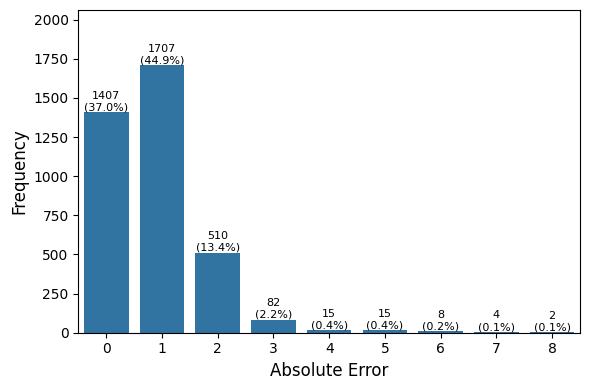

In [67]:
plot_count_with_labels(
    data=results_ext_nord,
    x='abs_error',
    #title='Extreme Nord - Total Cases',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


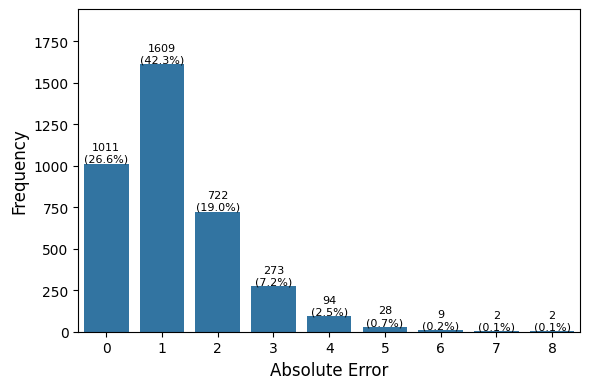

In [68]:
plot_count_with_labels(
    data=results_ext_nord_severe,
    x='abs_error',
    #title='Extreme Nord - Total Severe Cases',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


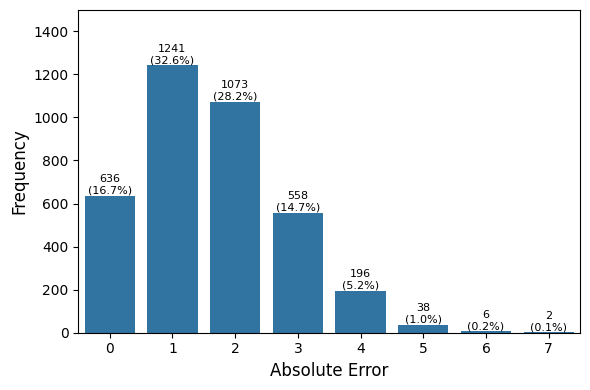

In [ ]:
plot_count_with_labels(
    data=results_ext_nord_hosp,
    x='abs_error',
    #title='Extreme Nord - Total Hospitalizations',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


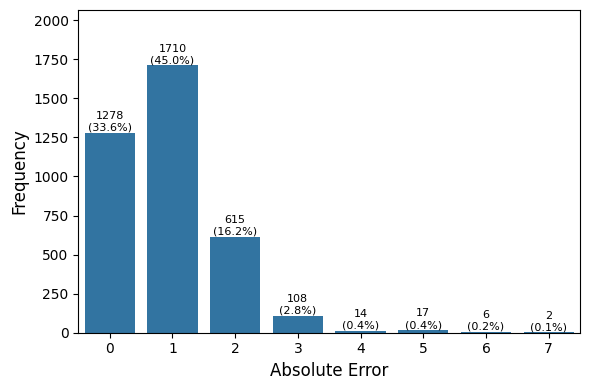

In [70]:
plot_count_with_labels(
    data=results_ext_nord_und5,
    x='abs_error',
    #title='Extreme Nord - Cases Under 5',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


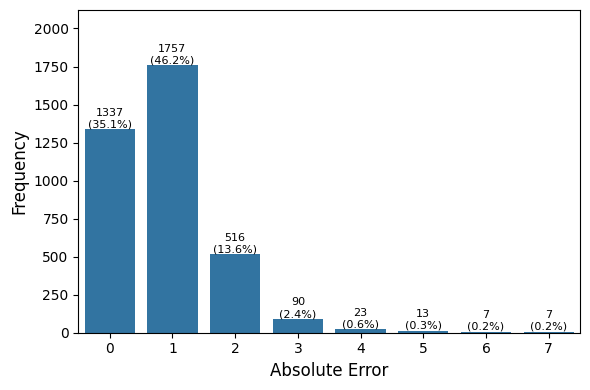

In [71]:
plot_count_with_labels(
    data=results_ext_nord_ovr5,
    x='abs_error',
    #title='Extreme Nord - Cases Over 5',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


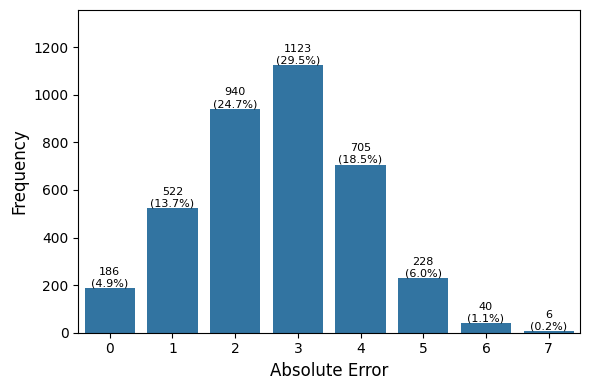

In [72]:
plot_count_with_labels(
    data=results_ext_nord_prgn,
    x='abs_error',
    #title='Extreme Nord - Cases Pregnant Women',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


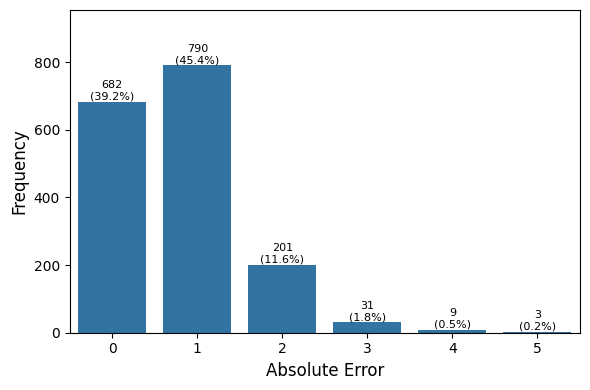

In [73]:
plot_count_with_labels(
    data=results_nord,
    x='abs_error',
    #title='Nord - Total Cases',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


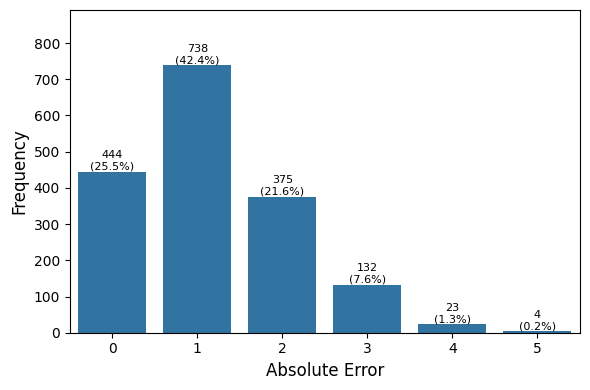

In [74]:
plot_count_with_labels(
    data=results_nord_severe,
    x='abs_error',
    #title='Nord - Total Severe Cases',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


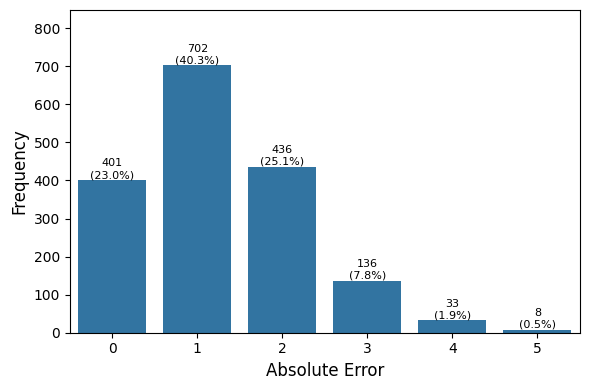

In [75]:
plot_count_with_labels(
    data=results_nord_hosp,
    x='abs_error',
    #title='Nord - Total Hospitalizations',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


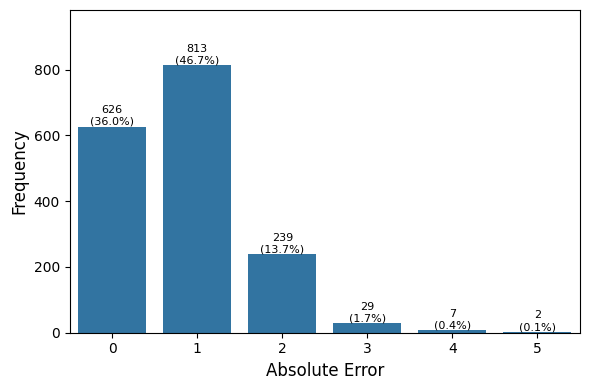

In [76]:
plot_count_with_labels(
    data=results_nord_und5,
    x='abs_error',
    #title='Nord - Cases Under 5',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


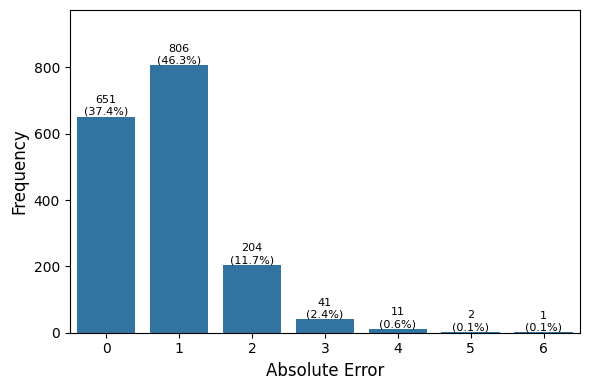

In [77]:
plot_count_with_labels(
    data=results_nord_ovr5,
    x='abs_error',
    #title='Nord - Cases Over 5',
    xlabel='Absolute Error'
)

plt.show()

C:\Users\dimit\AppData\Local\Temp\ipykernel_28956\2738011184.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


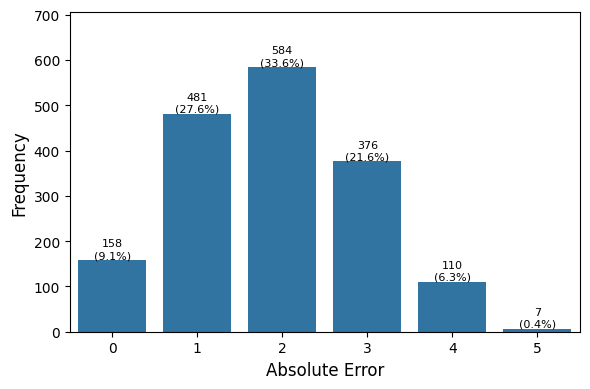

In [78]:
plot_count_with_labels(
    data=results_nord_prgn,
    x='abs_error',
    #title='Nord - Cases Pregnant Women',
    xlabel='Absolute Error'
)

plt.show()